In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.model_selection import RandomizedSearchCV
import pickle



In [3]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc

In [ ]:
df= pd.read_csv("project_seng474.csv")

In [ ]:
print(df.isnull().sum())
df=df.dropna()

In [ ]:
sns.distplot(df["recommendations"])

In [ ]:
df["recommendations"].describe()

count    64498.000000
mean       252.500543
std       1318.624671
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      42679.000000
Name: recommendations, dtype: float64

#KMeans CLustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score


Text(0, 0.5, 'Inertia')

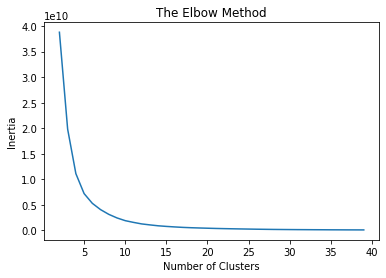

In [ ]:
# calculate k using python, with the elbow method
inertia = []

# define our possible k values
possible_K_values = [i for i in range(2,40)]

# we start with 2, as we can not have 0 clusters in k means, and 1 cluster is just a dataset

# iterate through each of our values
for each_value in possible_K_values:
    
    # iterate through, taking each value from 
    model = KMeans(n_clusters=each_value, init='k-means++',random_state=32)
    
    # fit it
    model.fit(df[["recommendations"]])
    
    # append the inertia to our array
    inertia.append(model.inertia_)

plt.plot(possible_K_values, inertia)
plt.title('The Elbow Method')

plt.xlabel('Number of Clusters')

plt.ylabel('Inertia')

In [ ]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(df[["recommendations"]])
y_kmeans = kmeans.predict(df[["recommendations"]])

In [ ]:
df['y_kmeans']=y_kmeans

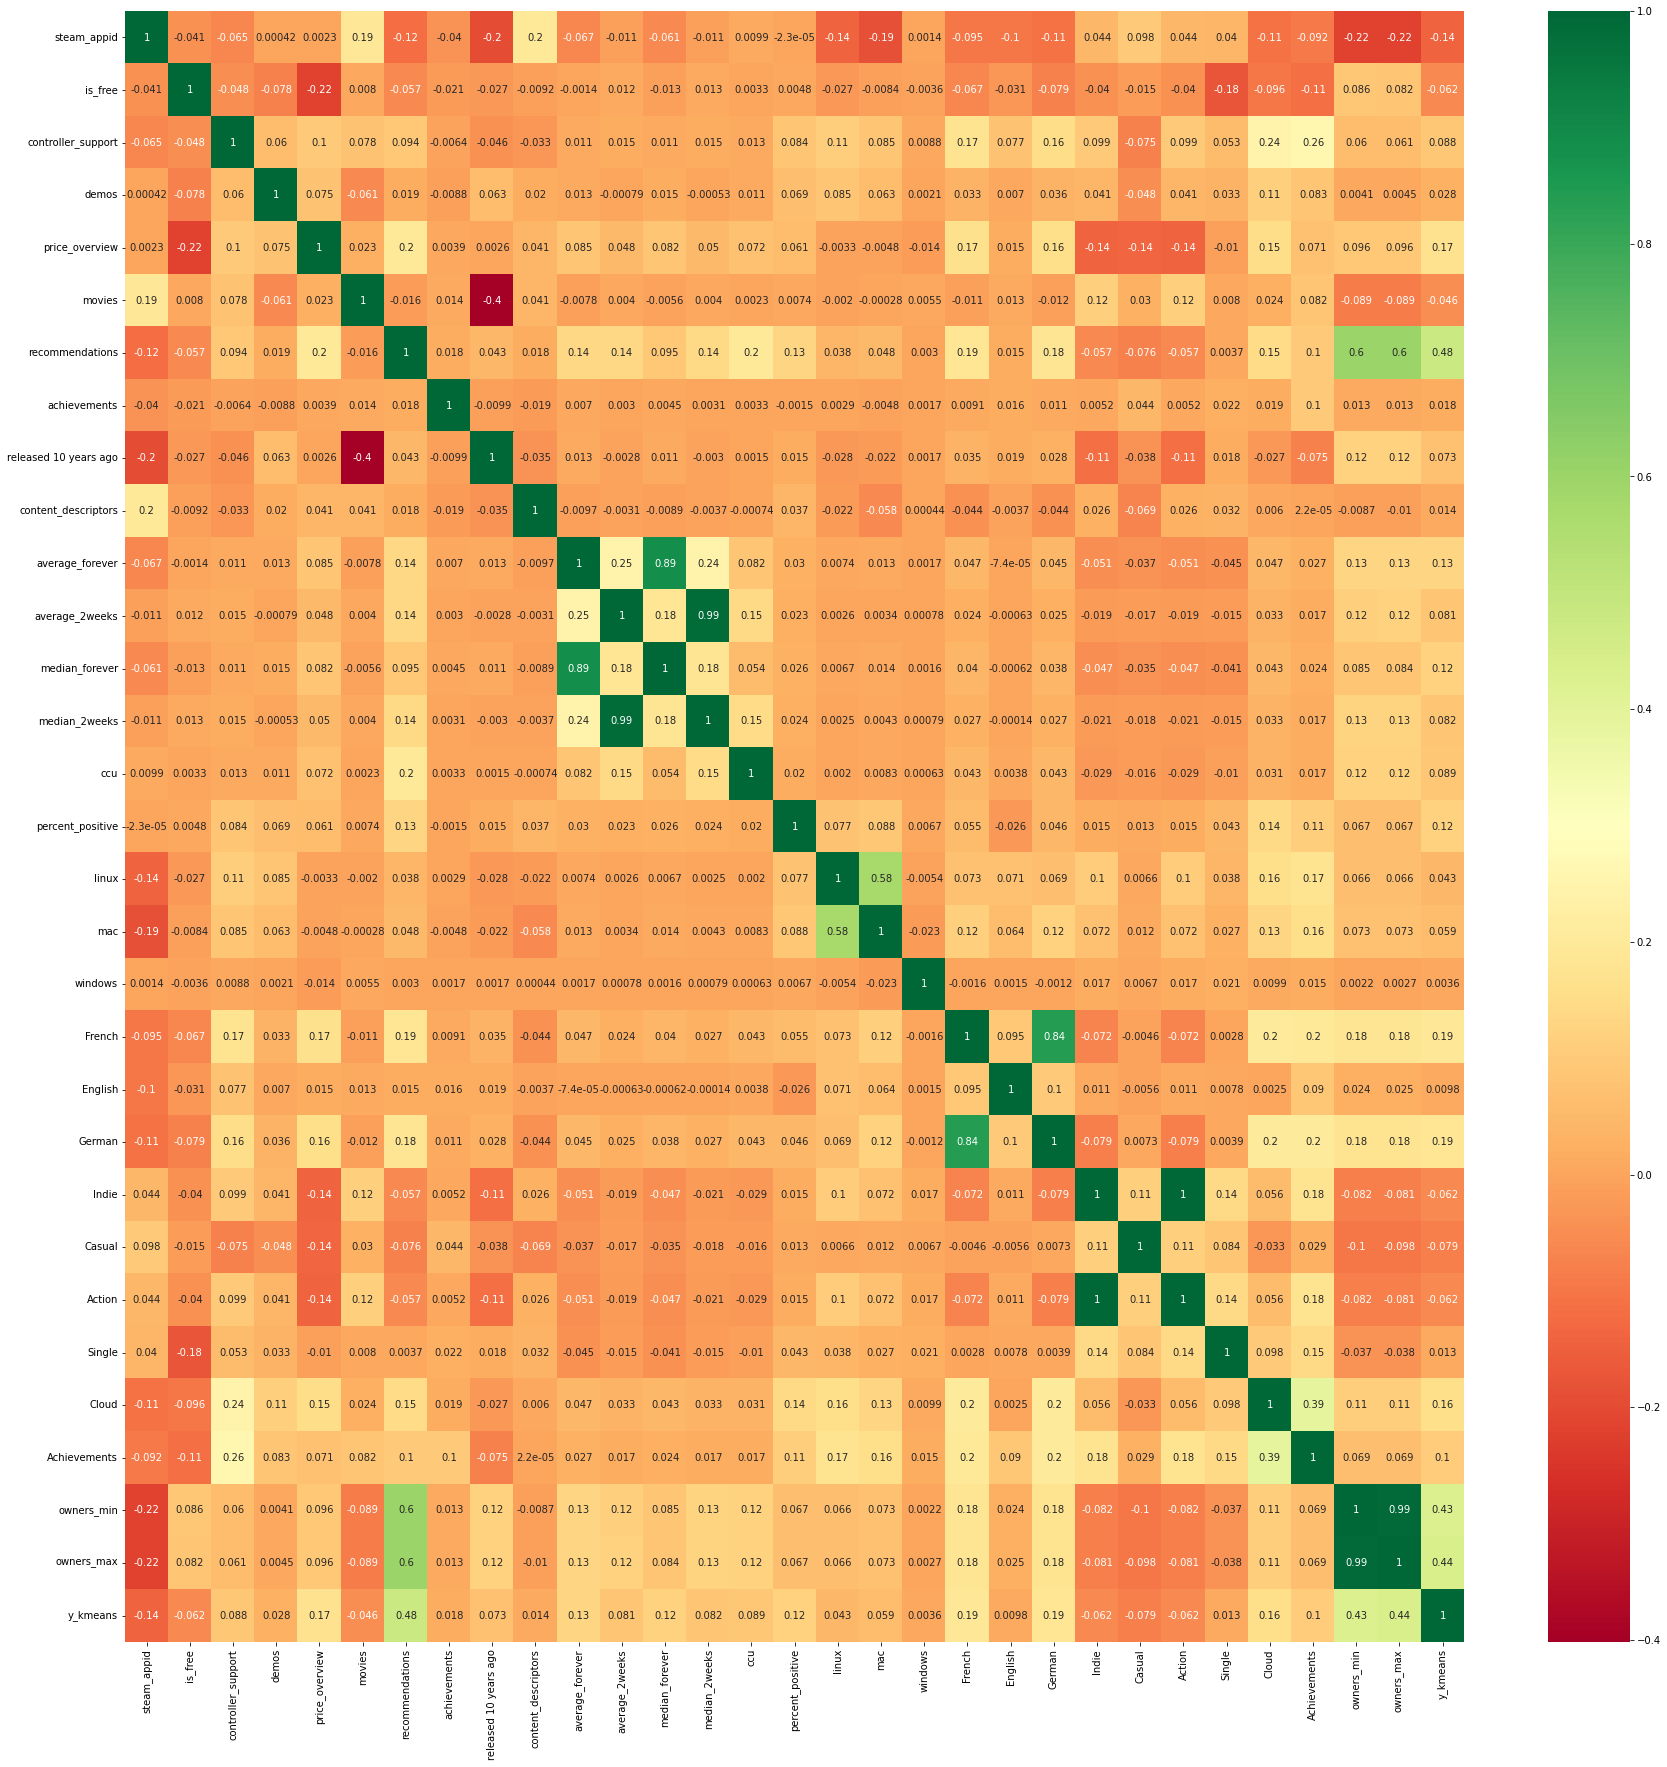

In [ ]:
fig, ax = plt.subplots(figsize=(30,30)) 
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn')

In [ ]:
df=df.drop("recommendations", axis=1)

In [ ]:
df['y_kmeans'].value_counts()

0    61338
4     2175
1      664
2      262
3       59
Name: y_kmeans, dtype: int64

In [ ]:
#Removing classes 1,2,3
df_partially_cleaned = df[(df["y_kmeans"] == 0) | (df["y_kmeans"] == 4)]

In [ ]:
df_partially_cleaned=df_partially_cleaned.drop("steam_appid", axis=1)

#Using SMOTE

In [ ]:
X=df_partially_cleaned.drop("y_kmeans",axis=1)
y=df_partially_cleaned["y_kmeans"]

In [ ]:
# define standard scaler
scaler = StandardScaler()
# transform data
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 42)

In [ ]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [ ]:
y_res.value_counts()

0    42933
4    42933
Name: y_kmeans, dtype: int64

#Calculating Feature Importance

In [ ]:
from sklearn.ensemble import RandomForestRegressor
# Instantiate model with 1000 decision trees
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)
# Train the model on training data
rf.fit(X_res, y_res)

RandomForestRegressor(random_state=42)

In [ ]:
feature_importances_list=[]

In [ ]:
rf.feature_importances_

array([1.25985695e-02, 1.09893381e-03, 1.38530744e-03, 1.11898418e-02,
       2.70027782e-03, 7.32680364e-03, 3.59163655e-04, 2.77303494e-03,
       4.50827569e-02, 1.60944929e-03, 7.91855618e-02, 1.35682584e-03,
       7.44146215e-01, 1.68129625e-02, 2.94823237e-03, 3.29699996e-03,
       0.00000000e+00, 2.10477597e-03, 4.02495255e-03, 1.72993641e-03,
       1.52472634e-03, 3.57891674e-03, 1.31677878e-03, 2.17643745e-03,
       5.69245205e-03, 2.89924762e-03, 2.07316603e-02, 2.03491800e-02])

In [ ]:
feature_importances_list=rf.feature_importances_

In [ ]:
b = feature_importances_list>0.04
r = np.where(b)[0]


In [ ]:
df_column_list=df_partially_cleaned.columns

In [ ]:
df_selected_column_list= [df_column_list[i] for i in r]


In [ ]:
len(df_selected_column_list)

3

In [ ]:
X_res=X_res[df_selected_column_list].copy()
X_test=X_test[df_selected_column_list].copy()

<BarContainer object of 28 artists>

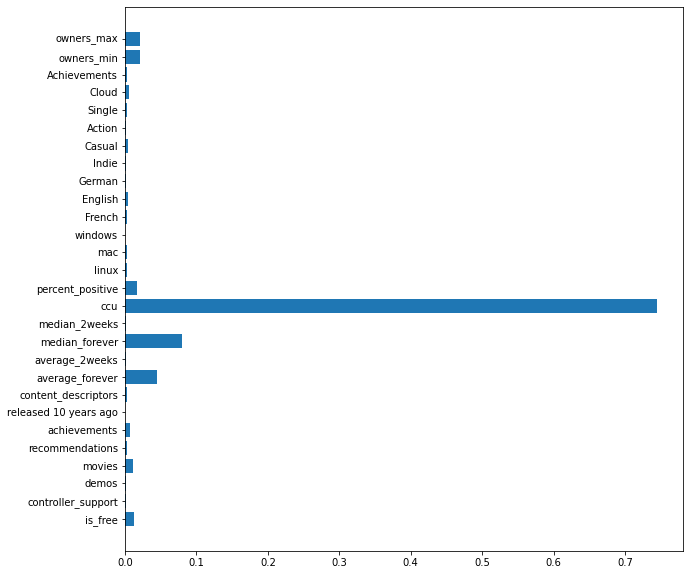

In [ ]:
fig, ax = plt.subplots(figsize=(10,10)) 

plt.barh(['is_free', 'controller_support', 'demos', 'movies',
       'recommendations', 'achievements', 'released 10 years ago',
       'content_descriptors', 'average_forever', 'average_2weeks',
       'median_forever', 'median_2weeks', 'ccu', 'percent_positive', 'linux',
       'mac', 'windows', 'French', 'English', 'German', 'Indie', 'Casual',
       'Action', 'Single', 'Cloud', 'Achievements', 'owners_min', 'owners_max',], rf.feature_importances_)


In [ ]:
#This function is used for:
#1) Train Test splitting the dataset & model fitting
#2) Hyperparmeter tuning the model using RandomizedSearchCV, 
#3) Generating the classfiication report and Confusion Matrix
#4) Getting the best set of Hyperparameters
#5) Getting Classification Report for Training set
#6) Getting Classification Report for Testing set

 
def Model_Driver_Function(x_train,x_test,y_train,y_test,algo_name,algorithm,gridSearchParams,cv,n_iter):

    #Setting the random seed to 101
    np.random.seed(101)
    

    #Using Grid serach for hyper-parameter tuning the model
    RandomizedSearchCV_grid = RandomizedSearchCV(
        estimator=algorithm,
        param_distributions=gridSearchParams,
        cv=cv, scoring='accuracy', verbose=1, n_jobs=-1,n_iter=n_iter,random_state=101)
    

    #Fitting the model
    RandomizedSearch_result = RandomizedSearchCV_grid.fit(x_train, y_train)


    #getting best parameters
    best_params = RandomizedSearch_result.best_params_

    #Getting the prediction against the Test Set
    prediction_test = RandomizedSearch_result.predict(x_test)

    #Getting the prediction against the Train Set
    prediction_train = RandomizedSearch_result.predict(x_train)

    #Getting the confusion matrix for training set
    cm_train = confusion_matrix(y_train, prediction_train)

    #Getting the confusion matrix for testing set
    cm_test = confusion_matrix(y_test, prediction_test)

    #Storing the model state into a pickle file
    pickle.dump(RandomizedSearch_result,open(algo_name,'wb'))


    print('\n\n')
    print('==============================================================================================')
    print('Best Model Hyper-parameters :',best_params)


    print('\n\n')
    print('==============================================================================================')
    print('Classification Report For Training set : \n',classification_report(y_train,prediction_train))

    print('\n\n')
    print('==============================================================================================')
    print('Classification Report For Testing set : \n',classification_report(y_test,prediction_test))

    print('\n\n')
    print('==============================================================================================')
    print('Confusion Matrix for Training Set :\n', cm_train)

    print('\n\n')
    print('==============================================================================================')
    print('Confusion Matrix for Testing Set :\n', cm_test)

  

#Developing Baseline Models
***
Developing models without using any balacning techniques for balancing the dataset

##Using XGBoost Classifier

In [ ]:
#Defining Hyper-parametrs for the XGBoost Classifier
param ={
    "n_estimators": [2000]
}

Model_Driver_Function(X_res,X_test,y_res,y_test,'XGBClassifier_baseline',XGBClassifier(tree_method = "gpu_hist", n_jobs=-1),param,cv=5,n_iter=50)

Fitting 5 folds for each of 1 candidates, totalling 5 fits



Best Model Hyper-parameters : {'n_estimators': 2000}



Classification Report For Training set : 
               precision    recall  f1-score   support

           0       0.98      0.97      0.97     42933
           4       0.97      0.98      0.97     42933

    accuracy                           0.97     85866
   macro avg       0.97      0.97      0.97     85866
weighted avg       0.97      0.97      0.97     85866




Classification Report For Testing set : 
               precision    recall  f1-score   support

           0       0.99      0.96      0.98     18405
           4       0.43      0.81      0.56       649

    accuracy                           0.96     19054
   macro avg       0.71      0.89      0.77     19054
weighted avg       0.97      0.96      0.96     19054




Confusion Matrix for Training Set :
 [[41506  1427]
 [  892 42041]]



Confusion Matrix for Testing Set :
 [[17703   702]
 [  123   526]]

##Using LightGBM Classifier

In [ ]:
#Defining Hyper-parametrs for the LightGBM Classifier
param ={
  'num_iterations': [2000],
}

Model_Driver_Function(X_res,X_test,y_res,y_test,'LightGBMClassifier_baseline',LGBMClassifier(),param,cv=5,n_iter=100)

Fitting 5 folds for each of 1 candidates, totalling 5 fits



Best Model Hyper-parameters : {'num_iterations': 2000}



Classification Report For Training set : 
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     42933
           4       1.00      0.99      1.00     42933

    accuracy                           1.00     85866
   macro avg       1.00      1.00      1.00     85866
weighted avg       1.00      1.00      1.00     85866




Classification Report For Testing set : 
               precision    recall  f1-score   support

           0       0.99      0.97      0.98     18405
           4       0.50      0.72      0.59       649

    accuracy                           0.97     19054
   macro avg       0.75      0.85      0.79     19054
weighted avg       0.97      0.97      0.97     19054




Confusion Matrix for Training Set :
 [[42866    67]
 [  245 42688]]



Confusion Matrix for Testing Set :
 [[17940   465]
 [  180   469